In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
gold = yf.download('GLD', start='2020-01-01', end='2025-01-01')



[*********************100%***********************]  1 of 1 completed


We will first extract Historial gold data for the years 2020-2025.

In [2]:
gold = gold['Close']



In [3]:
gold = np.array(gold)
sigma = np.std(gold)

# We want a good beta for this graph.



In [4]:
gold = gold[:,0]


In [5]:
print(gold)

[143.94999695 145.86000061 147.38999939 ... 241.3999939  240.63000488
 242.13000488]


In [6]:
returns = np.diff(np.log(gold))  # log returns


We try to find the best beta to fit the actual distrubtion of gold values.
Unfortunately turns out that this beta does not work with the CEV model to produce good results.

In [7]:
from scipy.optimize import minimize

S = gold[0]

def cev_error(beta):
    # predicted daily vol for each day
    vol_pred = np.std(returns / (S**beta))
    # compute squared error (simplest approach)
    return vol_pred

# minimize error over beta range
res = minimize(cev_error, x0=0.5, bounds=[(-1,2)])
best_beta = res.x[0]
print("Best beta for Gold:", best_beta)
#However turns out this beta value is way too high, and results in bad simulations for CEV

Best beta for Gold: 1.8036369649487538


We now compare actual gold values vs CEV simulations for beta = 0.12, 0 and -0.12. 
It is easy to see from the plots that a slightly positive beta (0.12) fits the real gold volatility quite well.

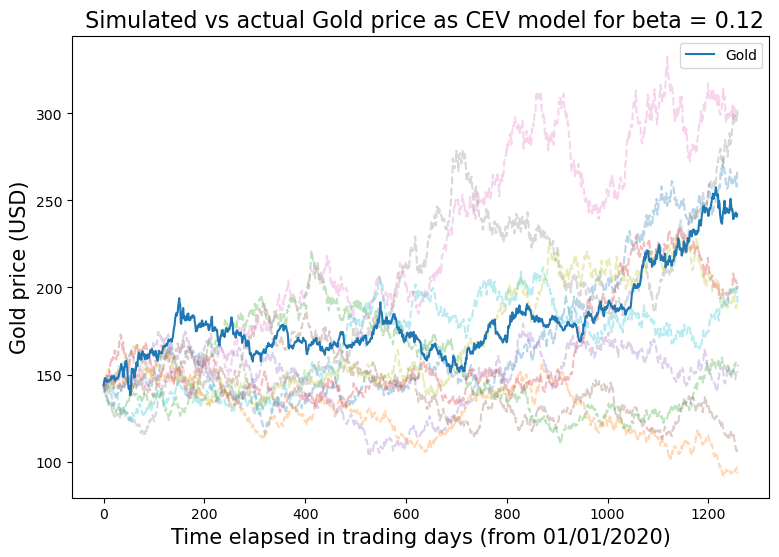

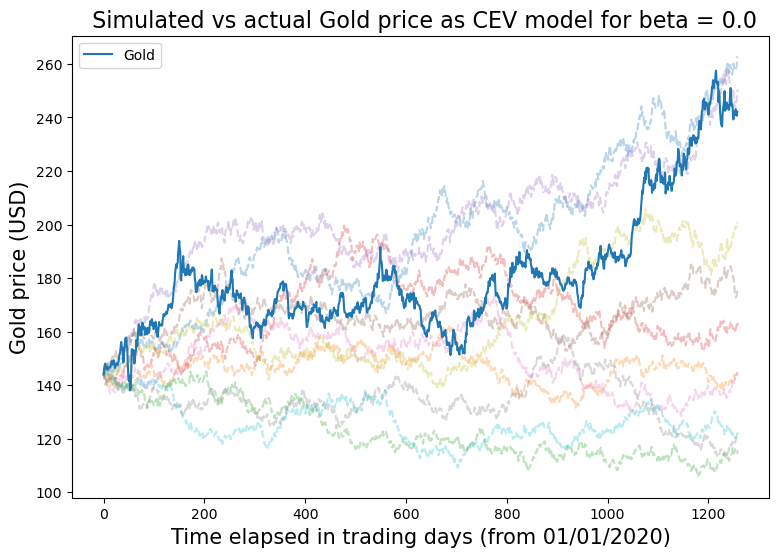

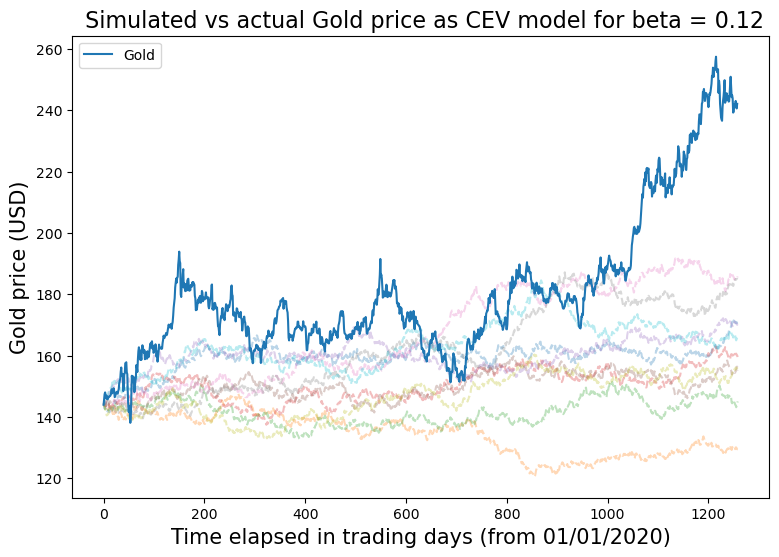

In [8]:
def f(beta=0):
    ##Sample from a standard normal distribution 
    N = len(gold)
    n_paths = 10
    r = 0.03
    dt = 5/N
    sigma = 0.1
    Z = np.random.randn(n_paths, N)
    paths = np.zeros((n_paths, N + 1))
    paths[:, 0] = gold[0]

    for t in range(N):
        S_t = paths[:, t]

        #Next discrete step using our standard normal distribution and current stock price (Markov process)
        paths[:, t+1] = S_t + (r * S_t * dt + sigma * (S_t ** (beta+1)) * np.sqrt(dt) * Z[:, t])

        #We don't want stock value to go below 0
        paths[:, t+1] = np.maximum(paths[:, t+1], 0)
    return paths
paths = f(0.12)
plt.figure(figsize = (9,6))

#times = np.linspace(0,5, len(gold)+1)

for path in paths:
    plt.plot( path, alpha = .3, ls = '--')

plt.plot( gold, label = 'Gold')
plt.title(f' Simulated vs actual Gold price as CEV model for beta = 0.12', size = 16)


plt.legend()
plt.ylabel('Gold price (USD)', size = 15)
plt.xlabel('Time elapsed in trading days (from 01/01/2020)', size = 15)
plt.show()

paths = f(0.0)
plt.figure(figsize = (9,6))

#times = np.linspace(0,5, len(gold)+1)

for path in paths:
    plt.plot( path, alpha = .3, ls = '--')

plt.plot( gold, label = 'Gold')
plt.title(f' Simulated vs actual Gold price as CEV model for beta = 0.0', size = 16)


plt.legend()
plt.ylabel('Gold price (USD)', size = 15)
plt.xlabel('Time elapsed in trading days (from 01/01/2020)', size = 15)
plt.show()

paths = f(-.12)
plt.figure(figsize = (9,6))

#times = np.linspace(0,5, len(gold)+1)

for path in paths:
    plt.plot( path, alpha = .3, ls = '--')

plt.plot( gold, label = 'Gold')
plt.title(f' Simulated vs actual Gold price as CEV model for beta = 0.12', size = 16)


plt.legend()
plt.ylabel('Gold price (USD)', size = 15)
plt.xlabel('Time elapsed in trading days (from 01/01/2020)', size = 15)
plt.show()